In [320]:
import matplotlib.pyplot as plt
#import numpy as np
import pandas as pd
import math

names_latency=['time_msec', 'latency', 'op2', 'write_size', 'op3']

### Uniform Random on HM-LS

time_msec           2245
latency       2245455906
op2                    1
write_size       1048576
op3                    0
Name: 0, dtype: int64
............
5.0
129.0
time_seconds        129.000000
bw                  154.000000
cumulative_gb         5.000000
cumulative_time    5515.000000
cumulative_bw        18.166667
dtype: float64
40.0MB/sec


<Figure size 640x480 with 0 Axes>

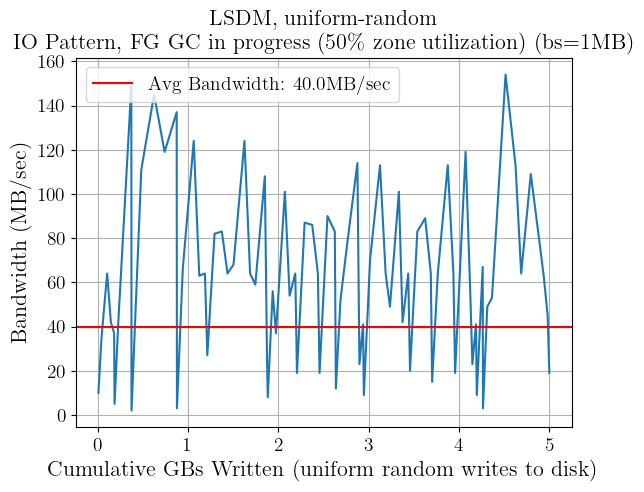

In [321]:
df_lat = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/50Util/1MB/8TB/uniform/lat_log_avg_lat.1.log', names=names_latency)
#df_lat['time_msec'] = df_lat['time_msec'].astype('float')
data0 = df_lat.iloc[0]
print(data0)
print('............')
df_lat['time_msec'] = df_lat['time_msec'] - data0.time_msec
df_lat['latency'] = df_lat['latency'] / (10 ** 6) # convert latency nsec to msec
df_lat['ctime_msec'] = df_lat['time_msec'] + df_lat['latency']

df_lat['write_size'] = df_lat['write_size'].astype(int)
df_lat['time_seconds'] = df_lat['ctime_msec'] / 1000  # Convert milliseconds to seconds
#df_lat['time_ssec'] = df_lat['time_msec']/1000

df_lat['time_seconds'] = df_lat['time_seconds'].astype(int)
df_binned = df_lat.groupby('time_seconds')['write_size'].sum().reset_index()
#frames = [df_lat_time, df_write_time['write_size']]
#df_binned = pd.concat(frames, axis='columns')

df_binned['cumulative_gb'] = df_binned['write_size'].cumsum() / (1024**3)
df_binned['cumulative_time'] = df_binned['time_seconds'].cumsum()
df_binned['cumulative_bw'] = (df_binned['cumulative_gb'] * 1024 )/df_binned['cumulative_time']
df_binned.columns = ['time_seconds', 'bw', 'cumulative_gb', 'cumulative_time', 'cumulative_bw'] # write size in 1 second is the definition of bandwidth.
 

df_binned['bw'] = df_binned['bw'] / (1024 ** 2) # bytes to MB
df_binned['bw'] = df_binned['bw']

data = df_binned.iloc[-1]
avg_bw = (data.cumulative_gb/data.time_seconds) * 1024
print(data.cumulative_gb)
print(data.time_seconds)
print(df_binned.max())
data0 = df_binned.iloc[0]
avg_bw = (data.cumulative_gb/(data.time_seconds - data0.time_seconds)) * 1024
avg_bw_str = str(round(avg_bw, 2)) + 'MB/sec'

print(avg_bw_str)

#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
ax.plot(df_binned['cumulative_gb'], df_binned['bw'], linestyle='-')
#ax.plot(df_binned['cumulative_gb'], df_binned['cumulative_bw'], linestyle=':')

# Add labels and title
plt.xlabel('Cumulative GBs Written (uniform random writes to disk)', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Bandwidth (MB/sec)', fontsize=16)
plt.yticks(fontsize=14)

plt.axhline(y=avg_bw, color='r', linestyle='-', label='Avg Bandwidth: ' + avg_bw_str)
plt.title('LSDM, uniform-random\nIO Pattern, FG GC in progress (50\% zone utilization) (bs=1MB)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/home/surbhi/github/surbhi-plots/LSDM/uniform-50Util-1MB.pdf', bbox_inches='tight')
plt.show()



5.0
208.0
24.62MB/sec


<Figure size 640x480 with 0 Axes>

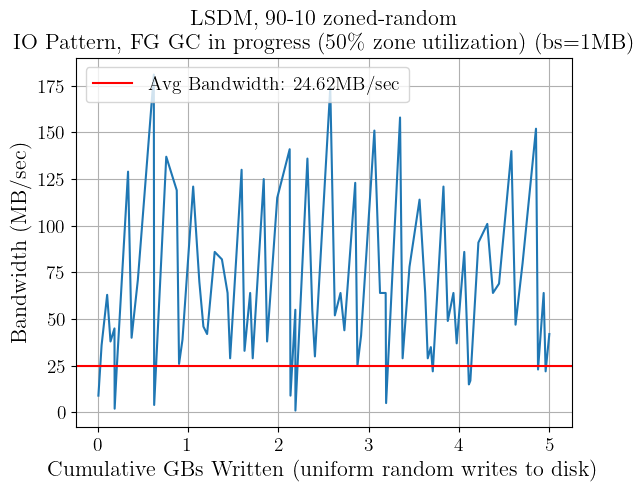

In [322]:
df_lat = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/50Util/1MB/8TB/90-10-zoned/lat_log_avg_lat.1.log', names=names_latency)
data0 = df_lat.iloc[0]
df_lat['time_msec'] = df_lat['time_msec'] - data0.time_msec
df_lat['latency'] = df_lat['latency'] / (10 ** 6) # convert latency nsec to msec
df_lat['ctime_msec'] = df_lat['time_msec'] + df_lat['latency']
df_lat['write_size'] = df_lat['write_size'].astype(int)
df_lat['time_seconds'] = df_lat['ctime_msec'] / 1000  # Convert milliseconds to seconds
df_lat['time_seconds'] = df_lat['time_seconds'].astype(int)
df_binned = df_lat.groupby('time_seconds')['write_size'].sum().reset_index()
#frames = [df_lat_time, df_write_time['write_size']]
#df_binned = pd.concat(frames, axis='columns')
df_binned['cumulative_gb'] = df_binned['write_size'].cumsum() / (1024**3)
df_binned['cumulative_gb'] = df_binned['cumulative_gb'].astype(float)
df_binned.columns = ['time_seconds', 'bw', 'cumulative_gb'] # write size in 1 second is the definition of bandwidth.
df_binned['bw'] = df_binned['bw'] / (1024 ** 2) # bytes to MB
df_binned['bw'] = df_binned['bw']

data = df_binned.iloc[-1] 
avg_bw = (data.cumulative_gb/data.time_seconds) * 1024
print(data.cumulative_gb)
print(data.time_seconds)
avg_bw_str = str(round(avg_bw, 2)) + 'MB/sec'

print(avg_bw_str)

#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
ax.plot(df_binned['cumulative_gb'], df_binned['bw'], linestyle='-')

# Add labels and title
plt.xlabel('Cumulative GBs Written (uniform random writes to disk)', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Bandwidth (MB/sec)', fontsize=16)
plt.yticks(fontsize=14)

plt.axhline(y=avg_bw, color='r', linestyle='-', label='Avg Bandwidth: ' + avg_bw_str)
plt.title('LSDM, 90-10 zoned-random\nIO Pattern, FG GC in progress (50\% zone utilization) (bs=1MB)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/home/surbhi/github/surbhi-plots/LSDM/9010-zoned-50Util-1MB.pdf', bbox_inches='tight')
plt.show()

5.0
792.0
6.46MB/sec


<Figure size 640x480 with 0 Axes>

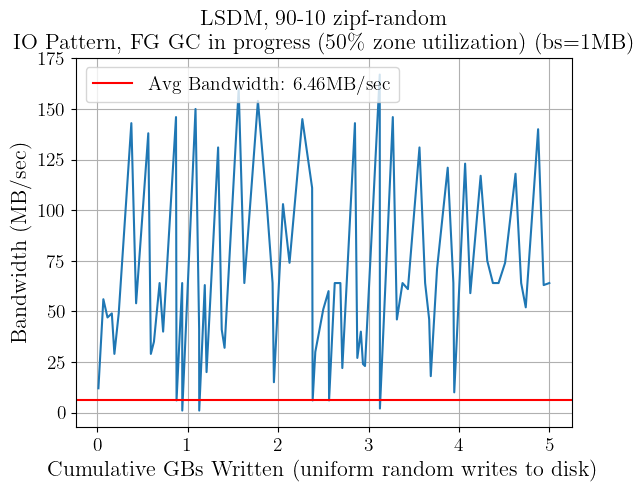

In [323]:
df_lat = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/50Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
data0 = df_lat.iloc[0]
df_lat['time_msec'] = df_lat['time_msec'] - data0.time_msec
df_lat['latency'] = df_lat['latency'] / (10 ** 6) # convert latency nsec to msec
df_lat['ctime_msec'] = df_lat['time_msec'] + df_lat['latency']
df_lat['write_size'] = df_lat['write_size'].astype(int)
df_lat['time_seconds'] = df_lat['ctime_msec'] / 1000  # Convert milliseconds to seconds
df_lat['time_seconds'] = df_lat['time_seconds'].astype(int)
df_binned = df_lat.groupby('time_seconds')['write_size'].sum().reset_index()
#frames = [df_lat_time, df_write_time['write_size']]
#df_binned = pd.concat(frames, axis='columns')
df_binned['cumulative_gb'] = df_binned['write_size'].cumsum() / (1024**3)
df_binned['cumulative_gb'] = df_binned['cumulative_gb'].astype(float)
df_binned.columns = ['time_seconds', 'bw', 'cumulative_gb'] # write size in 1 second is the definition of bandwidth.
df_binned['bw'] = df_binned['bw'] / (1024 ** 2) # bytes to MB

data = df_binned.iloc[-1]
print(data.cumulative_gb)
print(data.time_seconds)
data0 = df_binned.iloc[0]
avg_bw = (data.cumulative_gb/data.time_seconds) * 1024
avg_bw_str = str(round(avg_bw,2)) + 'MB/sec'

print(avg_bw_str)

#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
ax.plot(df_binned['cumulative_gb'], df_binned['bw'], linestyle='-')

# Add labels and title
plt.xlabel('Cumulative GBs Written (uniform random writes to disk)', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Bandwidth (MB/sec)', fontsize=16)
plt.yticks(fontsize=14)

plt.axhline(y=avg_bw, color='r', linestyle='-', label='Avg Bandwidth: ' + avg_bw_str)
plt.title('LSDM, 90-10 zipf-random\nIO Pattern, FG GC in progress (50\% zone utilization) (bs=1MB)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/home/surbhi/github/surbhi-plots/LSDM/9010-zipf-50Util-1MB.pdf', bbox_inches='tight')
plt.show()